In [1]:
import yfinance as yf

test = yf.download("MEBL.KA", start="2023-01-01", end="2025-12-31")
print(test.head())

/tmp/ipykernel_7087/3853127968.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test = yf.download("MEBL.KA", start="2023-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open   Volume
Ticker        MEBL.KA    MEBL.KA    MEBL.KA    MEBL.KA  MEBL.KA
Date                                                           
2023-01-02  68.994484  69.474091  67.829733  68.446368  1045918
2023-01-03  68.350433  69.337044  68.172293  68.686155   218223
2023-01-04  67.733788  68.925945  67.624161  68.925945   374911
2023-01-05  67.130875  68.206558  66.973288  67.487150   567575
2023-01-06  66.068893  67.624179  65.815387  67.144577  2489023


In [2]:
import yfinance as yf
import pandas as pd

#  baskets define
compliant = ["MEBL.KA", "SYS.KA", "EFERT.KA", "LUCK.KA"]
conventional = ["HBL.KA", "TRG.KA", "FFBL.KA", "DGKC.KA"]

all_tickers = compliant + conventional

data = yf.download(all_tickers, start="2023-01-01", end="2025-12-31")

close_prices = data['Close']

print(close_prices.head())
print(close_prices.shape)  # check  rows/columns

/tmp/ipykernel_7087/1037286279.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start="2023-01-01", end="2025-12-31")
[*********************100%***********************]  8 of 8 completed

Ticker        DGKC.KA   EFERT.KA    FFBL.KA     HBL.KA     LUCK.KA    MEBL.KA  \
Date                                                                            
2023-01-02  50.158562  51.201687  14.447216  47.082756  431.216400  68.994484   
2023-01-03  48.283939  51.233757  14.408767  46.425888  423.509918  68.350433   
2023-01-04  46.855656  51.323582  14.245358  46.549957  424.697784  67.733788   
2023-01-05  47.163132  51.323582  14.283807  47.111950  422.862000  67.130875   
2023-01-06  47.311913  51.362087  14.178073  46.739727  425.188660  66.068893   

Ticker          SYS.KA      TRG.KA  
Date                                
2023-01-02  469.401367  110.919998  
2023-01-03  472.681427  110.830002  
2023-01-04  472.554138  112.650002  
2023-01-05  478.585541  112.989998  
2023-01-06  486.457672  116.180000  
(764, 8)


In [5]:
import yfinance as yf
import pandas as pd


compliant = ["MEBL.KA", "SYS.KA", "EFERT.KA", "LUCK.KA"]
conventional = ["HBL.KA", "TRG.KA", "FFBL.KA", "DGKC.KA"]
all_tickers = compliant + conventional

data = yf.download(all_tickers, start="2023-01-01", end="2025-12-31")
close_prices = data['Close']

returns = close_prices.pct_change().dropna()

print("Close prices shape:", close_prices.shape)
print("Returns shape:", returns.shape)


/tmp/ipykernel_1500/3410410802.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start="2023-01-01", end="2025-12-31")
[*********************100%***********************]  8 of 8 completed

Close prices shape: (764, 8)
Returns shape: (763, 8)



/tmp/ipykernel_1500/3410410802.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = close_prices.pct_change().dropna()


In [6]:
close_prices.to_excel("stock_prices.xlsx")
returns.to_excel("daily_returns.xlsx")

from google.colab import files
files.download("stock_prices.xlsx")
files.download("daily_returns.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
volatility = returns.std() * (252**0.5)
print(volatility)

Ticker
DGKC.KA     0.396279
EFERT.KA    0.267080
FFBL.KA     0.337596
HBL.KA      0.342873
LUCK.KA     2.386409
MEBL.KA     0.293470
SYS.KA      2.385166
TRG.KA      0.458772
dtype: float64


In [8]:
compliant_vol = volatility[compliant].mean()
conventional_vol = volatility[conventional].mean()

print("Compliant basket avg volatility:", compliant_vol)
print("Conventional basket avg volatility:", conventional_vol)

Compliant basket avg volatility: 1.3330313126227469
Conventional basket avg volatility: 0.3838798890120666


In [9]:
print("LUCK max/min daily return:", returns['LUCK.KA'].max(), returns['LUCK.KA'].min())
print("SYS max/min daily return:", returns['SYS.KA'].max(), returns['SYS.KA'].min())

LUCK max/min daily return: 3.9598360617655404 -0.7994987326196962
SYS max/min daily return: 3.9556161780853296 -0.8062342088266994


In [10]:
returns_clean = returns.clip(lower=-0.5, upper=0.5)

volatility_clean = returns_clean.std() * (252**0.5)
print(volatility_clean)

compliant_vol = volatility_clean[compliant].mean()
conventional_vol = volatility_clean[conventional].mean()
print("Compliant basket avg volatility:", compliant_vol)
print("Conventional basket avg volatility:", conventional_vol)

Ticker
DGKC.KA     0.396279
EFERT.KA    0.267080
FFBL.KA     0.337596
HBL.KA      0.342873
LUCK.KA     0.586526
MEBL.KA     0.293470
SYS.KA      0.657740
TRG.KA      0.458772
dtype: float64
Compliant basket avg volatility: 0.45120402064100246
Conventional basket avg volatility: 0.3838798890120666


In [11]:
risk_free_rate = 0.10  # Pakistan roughly 10% risk-free rate (T-bill yield approx)

avg_daily_return = returns_clean.mean() * 252  # annualized return
sharpe_ratio = (avg_daily_return - risk_free_rate) / volatility_clean

print(sharpe_ratio)

Ticker
DGKC.KA     1.244176
EFERT.KA    1.559932
FFBL.KA     1.649439
HBL.KA      1.694854
LUCK.KA     0.592749
MEBL.KA     1.874132
SYS.KA     -0.268313
TRG.KA     -0.295994
dtype: float64


In [12]:
compliant_sharpe = sharpe_ratio[compliant].mean()
conventional_sharpe = sharpe_ratio[conventional].mean()

print("Compliant basket avg Sharpe:", compliant_sharpe)
print("Conventional basket avg Sharpe:", conventional_sharpe)

Compliant basket avg Sharpe: 0.9396250330293361
Conventional basket avg Sharpe: 1.0731187974447973


In [13]:
VaR_95 = returns_clean.quantile(0.05)
print(VaR_95)

compliant_VaR = VaR_95[compliant].mean()
conventional_VaR = VaR_95[conventional].mean()

print("Compliant basket avg VaR:", compliant_VaR)
print("Conventional basket avg VaR:", conventional_VaR)

Ticker
DGKC.KA    -0.032431
EFERT.KA   -0.022393
FFBL.KA    -0.024696
HBL.KA     -0.024985
LUCK.KA    -0.026989
MEBL.KA    -0.021058
SYS.KA     -0.029708
TRG.KA     -0.041970
Name: 0.05, dtype: float64
Compliant basket avg VaR: -0.025037271892415145
Conventional basket avg VaR: -0.0310206523915544


In [21]:
compliant_return = avg_daily_return[compliant].mean()
conventional_return = avg_daily_return[conventional].mean()

print("Compliant basket avg annual return:", compliant_return)
print("Conventional basket avg annual return:", conventional_return)

Compliant basket avg annual return: 0.3844527103703333
Conventional basket avg annual return: 0.47380235872029997


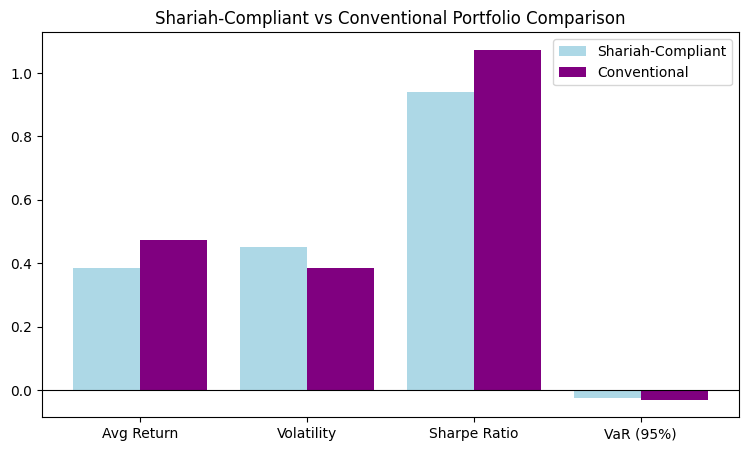

In [23]:
import matplotlib.pyplot as plt

metrics = ['Avg Return', 'Volatility', 'Sharpe Ratio', 'VaR (95%)']
compliant_values = [compliant_return, compliant_vol, compliant_sharpe, compliant_VaR]
conventional_values = [conventional_return, conventional_vol, conventional_sharpe, conventional_VaR]

x = range(len(metrics))
plt.figure(figsize=(9,5))
plt.bar([i-0.2 for i in x], compliant_values, width=0.4, label='Shariah-Compliant', color='lightblue')
plt.bar([i+0.2 for i in x], conventional_values, width=0.4, label='Conventional', color='purple')
plt.xticks(x, metrics)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.title('Shariah-Compliant vs Conventional Portfolio Comparison')
plt.show()